Energy Consumption Time Series Forecasting

In [15]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

2. Load Dataset

In [16]:
df = pd.read_csv(
    r"G:\Data Science\DS 27\Data\household_power_consumption.txt",
    sep=';',
    parse_dates={'Datetime':['Date','Time']},
    low_memory=False,
    na_values='?'
)

df.head()

C:\Users\YS\AppData\Local\Temp\ipykernel_5000\861773460.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\YS\AppData\Local\Temp\ipykernel_5000\861773460.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


3. Data Cleaning

In [17]:
# What we are doing:
# Convert power column into numeric format and remove missing values.

df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

df.dropna(inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 140.7 MB
None


4. Set Datetime Index

In [18]:
# Why:
# Time series models require datetime indexing.

df.set_index('Datetime', inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


5. Resample Time Series Data

In [19]:
# What we are doing:
# Convert minute-level readings into hourly averages.

hourly_df = df.resample('H').mean()
hourly_df.head()

C:\Users\YS\AppData\Local\Temp\ipykernel_5000\1715158668.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.resample('H').mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


6. Visualize Energy Consumption Trend

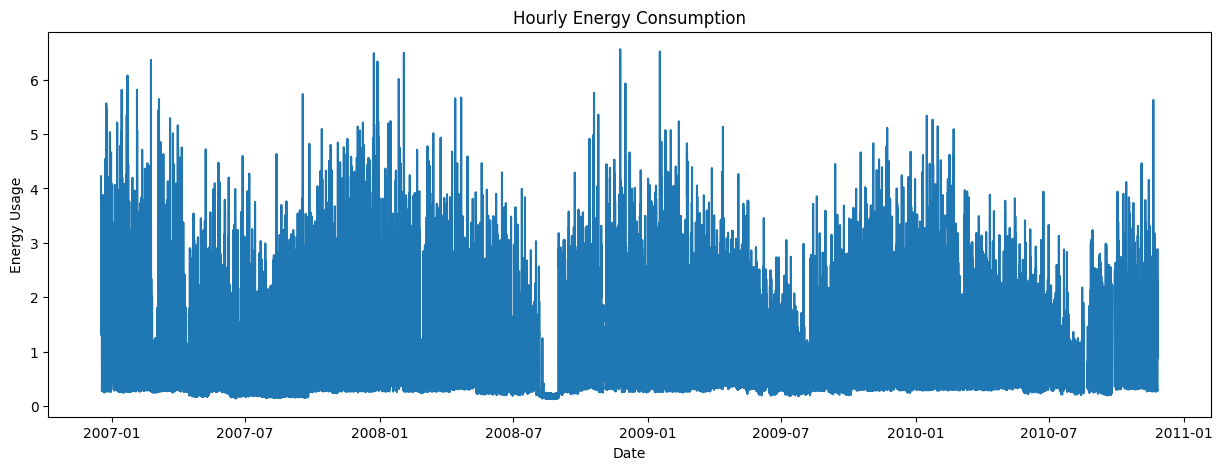

In [20]:
plt.figure(figsize=(15,5))

plt.plot(
    hourly_df.index,
    hourly_df['Global_active_power']
)

plt.title("Hourly Energy Consumption")

plt.xlabel("Date")

plt.ylabel("Energy Usage")

plt.show()

7. Feature Engineering

In [21]:
hourly_df['hour'] = hourly_df.index.hour

hourly_df['day'] = hourly_df.index.day

hourly_df['month'] = hourly_df.index.month

hourly_df['weekday'] = hourly_df.index.weekday

hourly_df['weekend'] = np.where(
    hourly_df['weekday']>=5,
    1,
    0
)

8. Advanced Feature Engineering (Lag Features)

In [22]:
# Why:
# Previous energy values help predict future values.

hourly_df['lag_1'] = hourly_df[
    'Global_active_power'
].shift(1)

hourly_df['lag_24'] = hourly_df[
    'Global_active_power'
].shift(24)

hourly_df['rolling_mean_24'] = hourly_df[
    'Global_active_power'
].rolling(24).mean()

9. Remove Null Values Created by Lags

In [23]:
hourly_df.dropna(inplace=True)
hourly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,weekday,weekend,lag_1,lag_24,rolling_mean_24
Datetime,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,17,12,6,1,3.326033,4.222889,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,17,12,6,1,3.406767,3.632200,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,17,12,6,1,3.697100,3.400233,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,17,12,6,1,2.908400,3.268567,2.451224
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,17,12,6,1,3.361500,3.056467,2.450569


10. Train-Test Split

In [24]:
# Use chronological split.

train_size = int(
    len(hourly_df)*0.80
)

train = hourly_df.iloc[:train_size]

test = hourly_df.iloc[train_size:]

11. ARIMA Model

In [25]:
# Statistical Time Series Forecasting

arima_model = ARIMA(
    train['Global_active_power'],
    order=(5,1,0)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

C:\Users\YS\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\YS\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\YS\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\YS\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer

12. Prophet Model

In [26]:
# Facebook/Meta forecasting model.

prophet_train = train.reset_index()

prophet_train = prophet_train[
    ['Datetime','Global_active_power']
]

prophet_train.columns = ['ds','y']

prophet_model = Prophet()

prophet_model.fit(
    prophet_train
)

15:33:32 - cmdstanpy - INFO - Chain [1] start processing
15:33:49 - cmdstanpy - INFO - Chain [1] done processing


    Forecasting

In [27]:
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq='H'
)

forecast = prophet_model.predict(
    future
)

prophet_pred = forecast[
    'yhat'
].iloc[-len(test):].values

C:\Users\YS\AppData\Roaming\Python\Python310\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


13. XGBoost Model

In [28]:
features = [
    'hour',
    'day',
    'month',
    'weekday',
    'weekend',
    'lag_1',
    'lag_24',
    'rolling_mean_24'
]

X_train = train[features]

y_train = train[
    'Global_active_power'
]

X_test = test[features]

y_test = test[
    'Global_active_power'
]

In [29]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

14. Model Evaluation

In [30]:
# Compare MAE and RMSE.

def evaluate(
    actual,
    predicted,
    model_name
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    print(model_name)

    print("MAE:", round(mae,4))

    print("RMSE:", round(rmse,4))

    print("-"*35)

In [31]:
evaluate(
    y_test,
    arima_pred,
    "ARIMA"
)

evaluate(
    y_test,
    prophet_pred,
    "Prophet"
)

evaluate(
    y_test,
    xgb_pred,
    "XGBoost"
)

ARIMA
MAE: 1.368
RMSE: 1.5012
-----------------------------------
Prophet
MAE: 0.6542
RMSE: 0.8248
-----------------------------------
XGBoost
MAE: 0.3319
RMSE: 0.4765
-----------------------------------


15. Forecast Comparison Plot

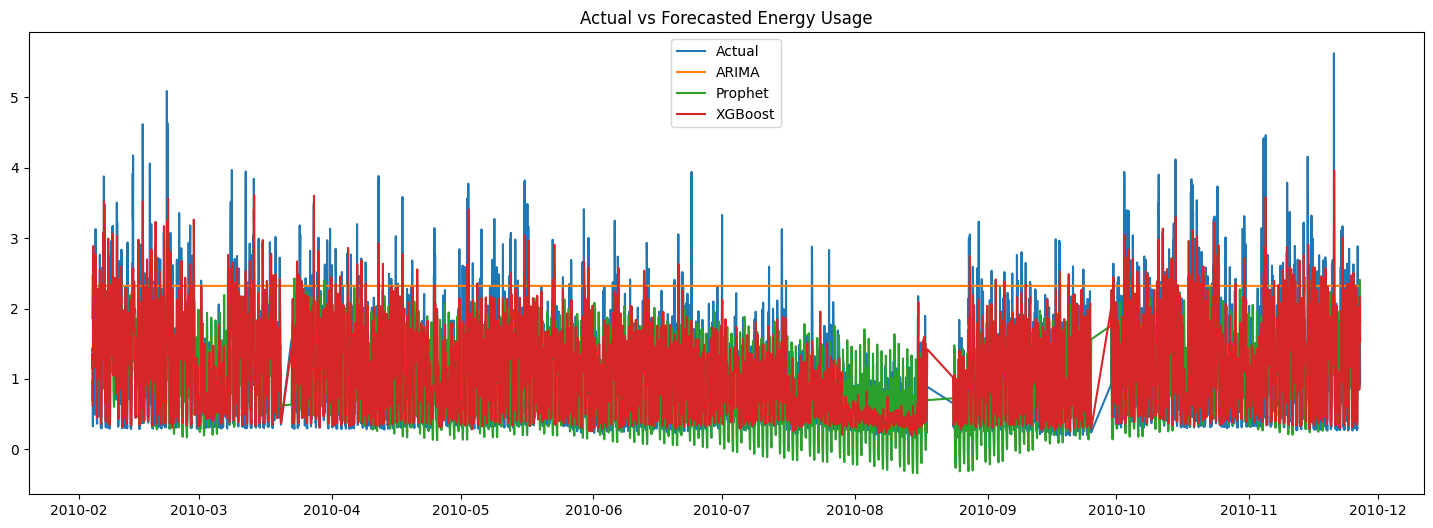

In [32]:
plt.figure(figsize=(18,6))

plt.plot(
    test.index,
    y_test,
    label='Actual'
)

plt.plot(
    test.index,
    arima_pred,
    label='ARIMA'
)

plt.plot(
    test.index,
    prophet_pred,
    label='Prophet'
)

plt.plot(
    test.index,
    xgb_pred,
    label='XGBoost'
)

plt.legend()

plt.title(
    "Actual vs Forecasted Energy Usage"
)

plt.show()

17. Business Insights

In [33]:
print("""
Business Insights:

1. Energy usage follows strong hourly patterns.

2. Weekday/weekend behavior affects energy demand.

3. Lag features significantly improve forecasting accuracy.

4. ARIMA captures historical trends.

5. Prophet captures trend and seasonality.

6. XGBoost leverages engineered features for stronger forecasting.
""")


Business Insights:

1. Energy usage follows strong hourly patterns.

2. Weekday/weekend behavior affects energy demand.

3. Lag features significantly improve forecasting accuracy.

4. ARIMA captures historical trends.

5. Prophet captures trend and seasonality.

6. XGBoost leverages engineered features for stronger forecasting.



18. Final Conclusion

In this project, I successfully developed a complete Time Series Forecasting system for household energy consumption using real-world data. The project began with data preprocessing where I parsed datetime information, cleaned missing values, and resampled the dataset into hourly energy usage patterns to make it suitable for time series analysis.

To improve prediction accuracy, I performed feature engineering by creating meaningful temporal variables such as hour of the day, day of the month, weekday/weekend indicators, and lag-based features. These features helped capture hidden patterns and dependencies in energy consumption behavior.

I implemented and compared three different forecasting approaches:

ARIMA, a statistical model for capturing historical trends and autocorrelation
Prophet, which effectively modeled seasonality and long-term trends
XGBoost, a machine learning approach that leveraged engineered features for more flexible and powerful predictions

To evaluate model performance, I used MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error), allowing a clear comparison of prediction accuracy across models. Additionally, I visualized the actual vs predicted energy usage, which provided a clear understanding of how each model performs over time.

Overall, this project demonstrates my ability to handle end-to-end time series forecasting workflows, including data preprocessing, feature engineering, model building, evaluation, and visualization. It also highlights my understanding of both statistical and machine learning-based forecasting techniques, and how they can be applied to real-world energy consumption problems.

This project strengthened my skills in:

Time Series Analysis
Feature Engineering for Temporal Data
Model Comparison (ARIMA, Prophet, XGBoost)
Performance Evaluation (MAE, RMSE)
Data-driven decision making